# Bài 1: Cài đặt Canny từ Đầu
1. Cài đặt toàn bộ pipeline Canny từ đầu bằng NumPy (không dùng cv2.Canny ở phần cốt lõi).

2. Cài đặt Otsu để tự động xác định τ high; so sánh kết quả với τ chỉnhtay
khi nào Otsu tốthơn,khi nào tệhơn? Giảithích.

3. So sánh implementation của bạn với cv2. Canny bằng chỉ số IoU (Inter section over Union).

4. Trả lời: nếu kết quả có quá nhiều cạnh giả, bạn điều chỉnh tham số nào trước tiên và theo hướng nào? Giải thích dựa trên cơ chế thuật toán.

In [1]:
import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import convolve

# Bài 1 – Cài đặt Canny Từ Đầu
**Môn:** Xử lý ảnh và Thị giác máy tính (121036)  
**Pipeline:** Gaussian Blur → Sobel → NMS → Otsu → Hysteresis  
> Toàn bộ cài đặt bằng **NumPy thuần**, không dùng `cv2.Canny` ở phần cốt lõi.

## 1. Gaussian Blur
**Mục đích:** làm mờ ảnh trước khi tính gradient, triệt tiêu nhiễu cao tần.  
Dùng *separable filter* (tích chập 1D theo hàng rồi cột) để tăng tốc.

$$G(x,y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2+y^2}{2\sigma^2}}$$

In [2]:
#yeu cau 1
def gaussian_blur(image: np.ndarray, sigma: float = 1.0) -> np.ndarray:
    """Gaussian blur dùng separable 1D kernel – thuần NumPy."""
    size = int(6 * sigma + 1) | 1   # kích thước lẻ
    k = size // 2
    x = np.arange(-k, k + 1, dtype=np.float64)
    g1d = np.exp(-x**2 / (2 * sigma**2))
    g1d /= g1d.sum()

    img = image.astype(np.float64)
    # Tích chập theo hàng rồi theo cột
    tmp = np.apply_along_axis(lambda r: np.convolve(r, g1d, mode='same'), 1, img)
    return np.apply_along_axis(lambda c: np.convolve(c, g1d, mode='same'), 0, tmp)

## 2. Sobel Gradient → M và θ
Kernel Sobel kết hợp đạo hàm hữu hạn + làm mịn Gaussian 1D theo chiều vuông góc:

$$G_x = \begin{bmatrix}-1&0&+1\\-2&0&+2\\-1&0&+1\end{bmatrix}*I \qquad
G_y = \begin{bmatrix}-1&-2&-1\\0&0&0\\+1&+2&+1\end{bmatrix}*I$$

$$M = \sqrt{G_x^2 + G_y^2}, \qquad \theta = \arctan\!\left(\frac{G_y}{G_x}\right)$$

> **Lưu ý:** θ vuông góc với đường cạnh thật, không phải song song.

In [3]:
#yeu cau 1
SOBEL_X = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float64)

SOBEL_Y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]], dtype=np.float64)

def sobel_gradient(image: np.ndarray):
    """Tính Gx, Gy, magnitude M và hướng theta (độ)."""
    Gx = convolve(image.astype(np.float64), SOBEL_X)
    Gy = convolve(image.astype(np.float64), SOBEL_Y)
    M  = np.hypot(Gx, Gy)
    theta = np.degrees(np.arctan2(Gy, Gx))   # [-180, 180]
    return Gx, Gy, M, theta

## 3. Non-maximum Suppression (NMS)
Giữ chỉ pixel có M là **cực đại cục bộ** dọc theo hướng gradient.

**Thuật toán:**
1. Lượng tử hoá θ về 4 hướng: 0°, 45°, 90°, 135°
2. Xác định 2 hàng xóm q1, q2 dọc theo hướng đó
3. Nếu M(p) < max(M(q1), M(q2)) → xoá p

Kết quả: cạnh dày 3–5 px → mỏng 1 px.

In [4]:
#yeu cau 1
def non_maximum_suppression(M: np.ndarray, theta: np.ndarray) -> np.ndarray:
    """NMS: chỉ giữ pixel là cực đại cục bộ dọc hướng gradient."""
    H, W = M.shape
    nms   = np.zeros_like(M)
    angle = theta % 180   # chuẩn hoá về [0, 180)

    for i in range(1, H - 1):
        for j in range(1, W - 1):
            a = angle[i, j]
            m = M[i, j]

            if   (0   <= a < 22.5) or (157.5 <= a < 180): q1, q2 = M[i, j-1], M[i, j+1]
            elif  22.5 <= a < 67.5:                         q1, q2 = M[i-1, j+1], M[i+1, j-1]
            elif  67.5 <= a < 112.5:                        q1, q2 = M[i-1, j],   M[i+1, j]
            else:                                            q1, q2 = M[i-1, j-1], M[i+1, j+1]

            if m >= q1 and m >= q2:
                nms[i, j] = m

    return nms

## 4. Otsu Thresholding (tự động chọn ngưỡng)
Otsu tìm τ* tối đa hoá **phương sai liên lớp** (between-class variance):

$$\tau^* = \arg\max_{\tau}\; \omega_0(\tau)\,\omega_1(\tau)\,\bigl[\mu_0(\tau) - \mu_1(\tau)\bigr]^2$$

Áp dụng lên histogram của M (sau NMS):  
→ `τhigh = τ*_Otsu`, `τlow = τhigh / 2`

In [5]:
#yeu cau 2
def otsu_threshold(M: np.ndarray, n_bins: int = 256):
    """Trả về (tau_high, tau_low) tự động từ histogram gradient M."""
    M_norm = M / M.max() * 255 if M.max() > 0 else M
    hist, _ = np.histogram(M_norm.flatten(), bins=n_bins, range=(0, 256))
    hist   = hist.astype(np.float64)
    total  = hist.sum()

    best_tau, best_var = 0, 0.0
    sum_total = np.dot(np.arange(n_bins), hist)
    sum_bg, w_bg = 0.0, 0.0

    for t in range(n_bins):
        w_bg  += hist[t];  sum_bg += t * hist[t]
        if w_bg == 0: continue
        w_fg = total - w_bg
        if w_fg == 0: break

        mu_bg = sum_bg / w_bg
        mu_fg = (sum_total - sum_bg) / w_fg
        var_b = w_bg * w_fg * (mu_bg - mu_fg) ** 2

        if var_b > best_var:
            best_var, best_tau = var_b, t

    tau_high = best_tau / 255.0 * M.max()
    return tau_high, tau_high / 2.0

## 5. Hysteresis Thresholding (DFS)
Phân loại pixel thành 3 nhóm:
- **Strong edge** (≥ τhigh): giữ chắc chắn
- **Weak edge** (τlow ≤ M < τhigh): giữ nếu **kết nối 8-chiều** với strong edge
- **Noise** (< τlow): loại bỏ

Dùng **DFS** (stack) để lan truyền đúng thứ tự — tránh lỗi single-pass.

In [6]:
#yeu cau 1
def hysteresis_thresholding(nms: np.ndarray,
                             tau_low: float,
                             tau_high: float) -> np.ndarray:
    """Edge tracking bằng DFS 8-connectivity."""
    H, W   = nms.shape
    strong = nms >= tau_high
    weak   = (nms >= tau_low) & ~strong
    result = np.zeros((H, W), dtype=np.uint8)
    result[strong] = 255

    visited = strong.copy()
    stack   = list(zip(*np.where(strong)))
    dirs    = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]

    while stack:
        ci, cj = stack.pop()
        for di, dj in dirs:
            ni, nj = ci+di, cj+dj
            if 0 <= ni < H and 0 <= nj < W and not visited[ni,nj] and weak[ni,nj]:
                visited[ni,nj] = True
                result[ni,nj]  = 255
                stack.append((ni, nj))
    return result

## 6. Pipeline Canny Đầy Đủ
Gộp tất cả bước trên vào một hàm duy nhất. Trả về dict chứa mọi bước trung gian.

In [7]:
#yeu cau 1
def canny_from_scratch(image: np.ndarray,
                       sigma: float = 1.0,
                       tau_low: float = None,
                       tau_high: float = None,
                       use_otsu: bool = True) -> dict:
    """Pipeline Canny đầy đủ — thuần NumPy."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if image.ndim == 3 else image
    gray = gray.astype(np.float64)

    blurred       = gaussian_blur(gray, sigma)
    _, _, M, theta = sobel_gradient(blurred)
    nms           = non_maximum_suppression(M, theta)

    if use_otsu or tau_high is None:
        th_auto, tl_auto = otsu_threshold(nms)
        th = tau_high if tau_high is not None else th_auto
        tl = tau_low  if tau_low  is not None else tl_auto
    else:
        th, tl = tau_high, tau_low

    edges = hysteresis_thresholding(nms, tl, th)

    return dict(gray=gray, blurred=blurred, M=M, theta=theta,
                nms=nms, tau_low=tl, tau_high=th, edges=edges)

## 7. Chỉ số IoU (Intersection over Union)
So sánh edge map của implementation với `cv2.Canny`:

$$\text{IoU} = \frac{|\text{pred} \cap \text{gt}|}{|\text{pred} \cup \text{gt}|}$$

In [8]:
#yeu cau 3
def compute_iou(pred: np.ndarray, gt: np.ndarray) -> float:
    p, g = pred > 0, gt > 0
    return (p & g).sum() / (p | g).sum() if (p | g).sum() > 0 else 1.0

## 8. Demo – Chạy Pipeline và Visualize
Tạo ảnh test tổng hợp (hình chữ nhật + đường tròn + đường thẳng + nhiễu Gaussian).

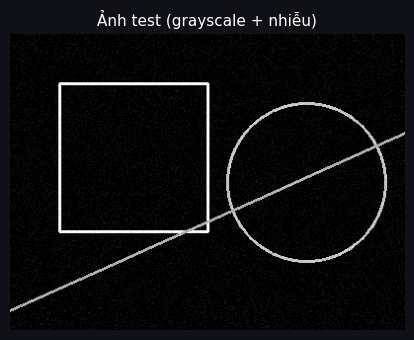

Kích thước ảnh: (300, 400)


In [9]:
# ── Tạo ảnh test ───────────────────────────────────────────────
img_gray = np.zeros((300, 400), dtype=np.uint8)
cv2.rectangle(img_gray, (50, 50),  (200, 200), 255, 2)
cv2.circle(   img_gray, (300, 150), 80,        200, 2)
cv2.line(     img_gray, (0, 280),  (400, 100), 180, 2)
noise = np.random.normal(0, 10, img_gray.shape).astype(np.int16)
img_gray = np.clip(img_gray.astype(np.int16) + noise, 0, 255).astype(np.uint8)

plt.figure(figsize=(5, 3.5), facecolor='#0f1117')
ax = plt.gca(); ax.set_facecolor('#0f1117')
ax.imshow(img_gray, cmap='gray')
ax.set_title('Ảnh test (grayscale + nhiễu)', color='white', fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.savefig('step0_input.png', dpi=110, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print(f'Kích thước ảnh: {img_gray.shape}')

In [10]:
# ── yeu cau 2 - so sánh Otsu vs tay
# ── Chạy phần Otsu + NMS trước (chưa hysteresis) ────────────────
SIGMA = 1.4

result_otsu = canny_from_scratch(img_gray, sigma=SIGMA, use_otsu=True)
th_o, tl_o  = result_otsu['tau_high'], result_otsu['tau_low']
print(f'Otsu tự động → τhigh = {th_o:.1f},  τlow = {tl_o:.1f}')

Otsu tự động → τhigh = 187.3,  τlow = 93.7


### 8.1. Nhìn Histogram để Tự Chọn Ngưỡng Tay
Theo tài liệu (mục 1.5): *"Luôn visualise histogram trước khi tin vào kết quả Otsu"*.

Trục y dùng log scale để các đỉnh nhỏ không bị che bởi đỉnh nền khổng lồ
(vùng phẳng luôn có số pixel gấp hàng chục–hàng trăm lần vùng cạnh).  
Đường đỏ nét đứt là gợi ý của Otsu; bạn tự **nhìn bằng mắt** và chọn τhigh phù hợp.

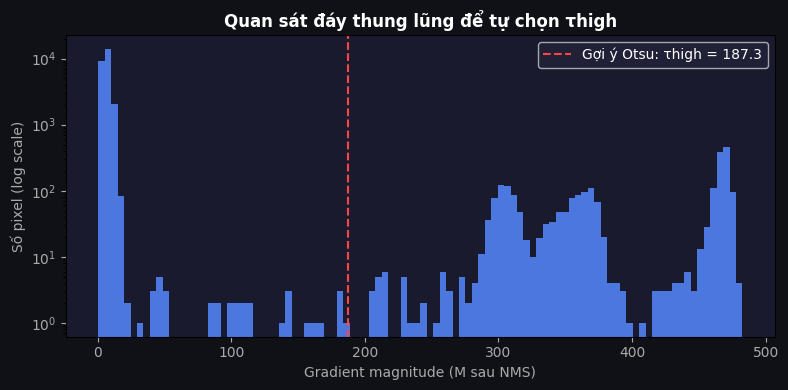

Gợi ý cách đọc:
  - Đỉnh bên trái (gần 0): pixel vùng phẳng, không phải cạnh.
  - Đỉnh bên phải (giá trị cao hơn): pixel cạnh thật.
  - τhigh nên đặt tại điểm THẤP NHẤT giữa hai đỉnh (đáy thung lũng), NẾU CÓ.
  - M lớn nhất trong ảnh: 482.5


In [11]:
# ── Vẽ histogram để chọn ngưỡng TAY bằng quan sát (log scale) ──
M_flat_preview = result_otsu['nms'].flatten()
M_flat_preview = M_flat_preview[M_flat_preview > 0]

plt.figure(figsize=(8, 4), facecolor='#0f1117')
ax = plt.gca(); ax.set_facecolor('#1a1a2e')
ax.tick_params(colors='#aaaaaa')
ax.hist(M_flat_preview, bins=100, color='#5588ff', alpha=0.85, edgecolor='none')
ax.set_yscale('log')   # log scale — quan trọng để thấy đỉnh nhỏ
ax.axvline(th_o, color='#ff4444', lw=1.5, ls='--',
           label=f'Gợi ý Otsu: τhigh = {th_o:.1f}')
ax.set_xlabel('Gradient magnitude (M sau NMS)', color='#aaaaaa')
ax.set_ylabel('Số pixel (log scale)', color='#aaaaaa')
ax.set_title('Quan sát đáy thung lũng để tự chọn τhigh',
              color='white', fontweight='bold')
ax.legend(facecolor='#22223a', labelcolor='white')
plt.tight_layout()
plt.show()

print('Gợi ý cách đọc:')
print('  - Đỉnh bên trái (gần 0): pixel vùng phẳng, không phải cạnh.')
print('  - Đỉnh bên phải (giá trị cao hơn): pixel cạnh thật.')
print('  - τhigh nên đặt tại điểm THẤP NHẤT giữa hai đỉnh (đáy thung lũng), NẾU CÓ.')
print(f'  - M lớn nhất trong ảnh: {M_flat_preview.max():.1f}')

### 8.2. Tự Đặt Giá Trị Ngưỡng Tay
Sau khi nhìn histogram ở trên, **tự điền số bạn quan sát được** vào hai biến dưới đây.
Nếu chưa chắc, có thể thử lần lượt 2–3 giá trị rồi xem ảnh kết quả ở bước sau —
đây chính là cách "chỉnh tay" thật sự (thử – quan sát – tinh chỉnh), khác với
Otsu (tính tự động từ công thức phương sai liên lớp).

In [12]:
# ── Tự chọn ngưỡng tay (THAY SỐ Ở ĐÂY sau khi nhìn histogram) ───
# Gợi ý: nhìn đồ thị ở trên, ước lượng giá trị M tại đáy thung lũng.
# Số mẫu dưới đây CHỈ LÀ VÍ DỤ KHỞI ĐẦU — hãy sửa lại theo ảnh thật của bạn.
TAU_HIGH_MANUAL = 150.0   # ← bạn tự đặt theo đáy thung lũng quan sát được
TAU_LOW_MANUAL  = TAU_HIGH_MANUAL / 2   # tỷ lệ 1:2 theo gợi ý tài liệu (mục 1.5)

print(f'Ngưỡng tay bạn chọn → τhigh = {TAU_HIGH_MANUAL:.1f},  τlow = {TAU_LOW_MANUAL:.1f}')
print(f'(So với Otsu tự động  → τhigh = {th_o:.1f},  τlow = {tl_o:.1f})')

Ngưỡng tay bạn chọn → τhigh = 150.0,  τlow = 75.0
(So với Otsu tự động  → τhigh = 187.3,  τlow = 93.7)


In [13]:
# ── Chạy hysteresis với ngưỡng tay vừa chọn + so sánh cv2 ───────
th_m, tl_m = TAU_HIGH_MANUAL, TAU_LOW_MANUAL
result_man = canny_from_scratch(img_gray, sigma=SIGMA,
                                 tau_high=th_m, tau_low=tl_m, use_otsu=False)

blurred_cv = cv2.GaussianBlur(img_gray, (0,0), SIGMA)
cv2_th     = int(np.clip(th_o * 2, 0, 255))
edges_cv2  = cv2.Canny(blurred_cv, cv2_th // 2, cv2_th)

iou_otsu = compute_iou(result_otsu['edges'], edges_cv2)
iou_man  = compute_iou(result_man['edges'],  edges_cv2)
print(f'IoU (Otsu vs cv2) = {iou_otsu:.4f}')
print(f'IoU (Tay  vs cv2) = {iou_man:.4f}')

IoU (Otsu vs cv2) = 0.6801
IoU (Tay  vs cv2) = 0.6794


## 9. Visualize – Các Bước Pipeline

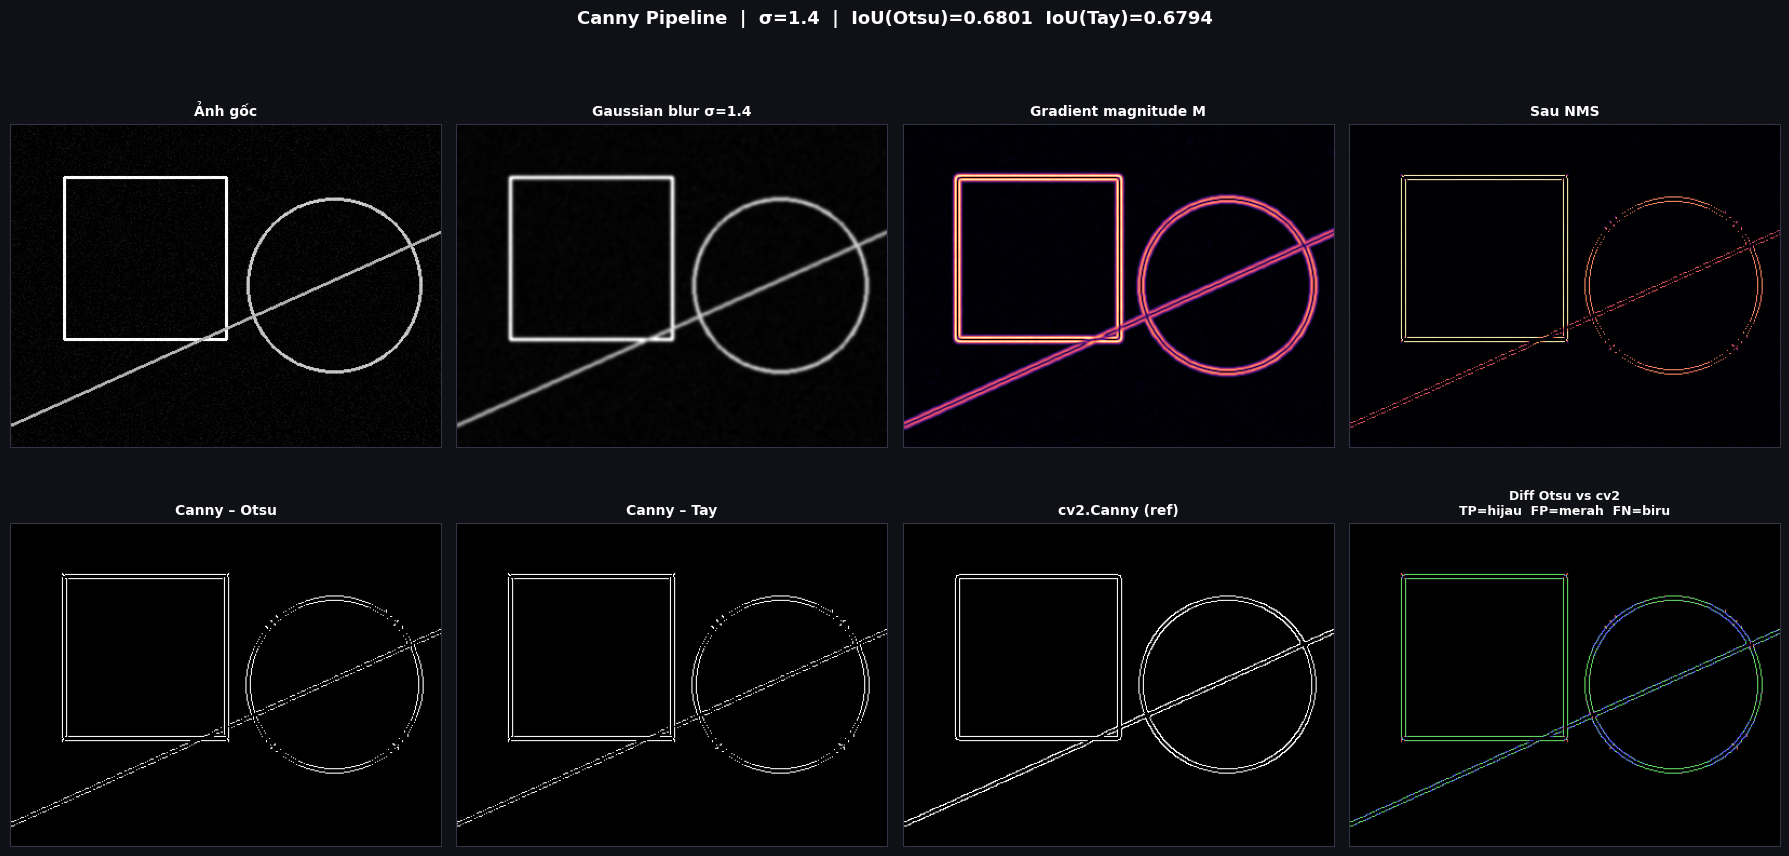

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9), facecolor='#0f1117')
fig.patch.set_facecolor('#0f1117')

steps = [
    (img_gray,                   'Ảnh gốc',              'gray'),
    (result_otsu['blurred'],     f'Gaussian blur σ={SIGMA}','gray'),
    (result_otsu['M'],           'Gradient magnitude M', 'magma'),
    (result_otsu['nms'],         'Sau NMS',              'magma'),
    (result_otsu['edges'],       'Canny – Otsu',         'gray'),
    (result_man['edges'],        'Canny – Tay',          'gray'),
    (edges_cv2,                  'cv2.Canny (ref)',       'gray'),
    (None,                       'Diff Otsu vs cv2',      None),
]

for idx, (ax, (data, title, cmap)) in enumerate(zip(axes.flat, steps)):
    ax.set_facecolor('#1a1a2e')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_edgecolor('#333344')
    if data is None:
        diff = np.zeros((*img_gray.shape, 3), dtype=np.uint8)
        p = result_otsu['edges'] > 0;  g = edges_cv2 > 0
        diff[p & g]   = [100, 220, 100]   # TP
        diff[p & ~g]  = [220, 80,  80 ]   # FP
        diff[~p & g]  = [80,  80,  220]   # FN
        ax.imshow(diff)
        ax.set_title('Diff Otsu vs cv2\nTP=hijau  FP=merah  FN=biru',
                     color='white', fontsize=9, fontweight='bold')
    else:
        ax.imshow(data, cmap=cmap)
        ax.set_title(title, color='white', fontsize=10, fontweight='bold')

fig.suptitle(f'Canny Pipeline  |  σ={SIGMA}  |  IoU(Otsu)={iou_otsu:.4f}  IoU(Tay)={iou_man:.4f}',
             color='white', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('canny_pipeline.png', dpi=120, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

## 10. Histogram Gradient M + Đường Ngưỡng Otsu

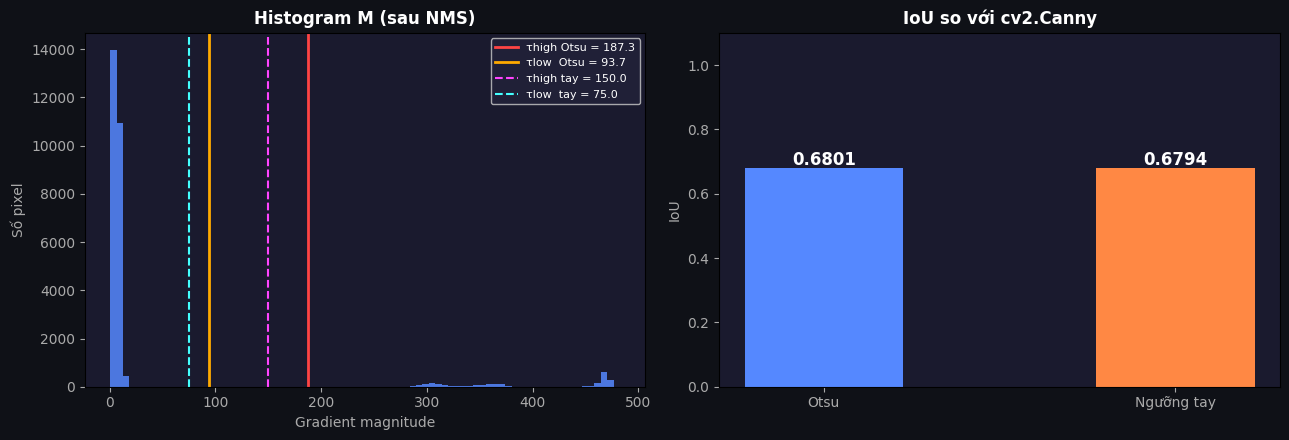

In [15]:
#yeu cau 2- yeu cau 3
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), facecolor='#0f1117')
fig.patch.set_facecolor('#0f1117')

for ax in (ax1, ax2):
    ax.set_facecolor('#1a1a2e')
    ax.tick_params(colors='#aaaaaa')

# Histogram
M_flat = result_otsu['nms'].flatten()
M_flat = M_flat[M_flat > 0]
ax1.hist(M_flat, bins=80, color='#5588ff', alpha=0.85, edgecolor='none')
ax1.axvline(th_o, color='#ff4444', lw=2, label=f'τhigh Otsu = {th_o:.1f}')
ax1.axvline(tl_o, color='#ffaa00', lw=2, label=f'τlow  Otsu = {tl_o:.1f}')
ax1.axvline(th_m, color='#ff44ff', lw=1.5, ls='--', label=f'τhigh tay = {th_m:.1f}')
ax1.axvline(tl_m, color='#44ffff', lw=1.5, ls='--', label=f'τlow  tay = {tl_m:.1f}')
ax1.set_xlabel('Gradient magnitude', color='#aaaaaa')
ax1.set_ylabel('Số pixel',           color='#aaaaaa')
ax1.set_title('Histogram M (sau NMS)', color='white', fontweight='bold')
ax1.legend(fontsize=8, facecolor='#22223a', labelcolor='white', framealpha=0.8)

# IoU bar
bars = ax2.bar(['Otsu', 'Ngưỡng tay'], [iou_otsu, iou_man],
               color=['#5588ff','#ff8844'], width=0.45)
for bar, val in zip(bars, [iou_otsu, iou_man]):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f'{val:.4f}', ha='center', color='white', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1.1)
ax2.set_title('IoU so với cv2.Canny', color='white', fontweight='bold')
ax2.set_ylabel('IoU', color='#aaaaaa')

plt.tight_layout()
plt.savefig('canny_histogram_iou.png', dpi=120,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

Yeu cau 2 - ## 11. Phân tích – Khi nào Otsu tốt hơn? Khi nào tệ hơn?

### Otsu tốt hơn khi:
- **Histogram bimodal rõ ràng**: vùng phẳng (gradient thấp) và vùng cạnh (gradient cao) tách biệt nhau.  
- Ảnh có đối tượng rõ nét trên nền đồng nhất (ví dụ: văn bản, bảng, đường kẻ).  
- Không cần thử-sai, tiết kiệm thời gian.

### Otsu tệ hơn khi:
- **Histogram unimodal**: ảnh kết cấu dày đặc (vải, cỏ, tường gạch) → không có "thung lũng" để phân tách.  
- Tỷ lệ pixel cạnh rất nhỏ (< 5%) → đỉnh cạnh bị "chìm" trong đỉnh nền, Otsu chọn ngưỡng quá cao.  
- Ảnh có nhiều mức gradient liên tục (ảnh y tế như MRI/CT).  

**Kết luận:** luôn visualise histogram M trước khi tin vào Otsu.  
Nếu histogram không rõ bimodal → điều chỉnh ngưỡng thủ công hoặc dùng percentile.

Yeu cau 4 - ## 12. Phân tích – Quá nhiều cạnh giả, điều chỉnh gì trước?

### Ưu tiên theo thứ tự:

**① Tăng `τhigh` (tác động mạnh nhất, ngay lập tức)**  
Hysteresis chỉ *promote* weak edge nếu nó **kết nối với strong edge**.  
Tăng `τhigh` → ít strong edge hơn → chuỗi DFS ngắn lại → phần lớn cạnh giả bị loại.  
Đây là điểm kiểm soát chính vì nó cắt ngay "gốc rễ" của chuỗi hysteresis.

**② Tăng `τlow` (loại weak edge cô lập yếu)**  
Nếu còn cạnh giả sau bước ①: tăng `τlow` → weak edge phải đủ mạnh hơn mới được promote.

**③ Tăng `σ` (nếu nhiễu lan rộng về không gian)**  
Gaussian kernel rộng hơn triệt tiêu gradient giả do nhiễu *trước* khi Sobel chạy.  
Hạn chế: σ lớn làm mờ chi tiết thật (nét mảnh, góc nhọn).

**Không nên** chỉnh Sobel kernel trước tiên — ảnh hưởng ít nhất đến cạnh giả.

```
Thứ tự thực tế: τhigh ↑  →  τlow ↑  →  σ ↑
```

# Bài 2: Multi-scale Hough Transform
1. Xây accumulator Hough từ đầu với ít nhất hai mức phân giải (coarse và fine).

2. Cài đặt coarse-to-fine: tìm ứng viên ở coarse, refine ở fine.

3. Cài đặt top-k peaks với NMS trên accumulator. So sánh kết quả khi k =1,3,5 trên ảnh bàn cờ– k nào phù hợp nhất và tại sao?

4. Cài đặt gradient-directed windowed voting. Vẽ đồ thị F1 vs window size (từ 5° đến 90°). Tìm và giải thích điểm “elbow”.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
def build_hough_accumulator(edge_map, rho_res, theta_res):
    H, W = edge_map.shape
    dmax = int(np.ceil(np.sqrt(H**2 + W**2)))

    rhos = np.arange(-dmax, dmax, rho_res)
    thetas = np.deg2rad(np.arange(0, 180, theta_res))

    num_rhos = len(rhos)
    num_thetas = len(thetas)
    accumulator = np.zeros((num_rhos, num_thetas), dtype=np.int32)

    y_idxs, x_idxs = np.where(edge_map > 0)

    cos_t = np.cos(thetas)
    sin_t = np.sin(thetas)

    for i in range(len(x_idxs)):
        x = x_idxs[i]
        y = y_idxs[i]
        for t_idx in range(num_thetas):
            rho = x * cos_t[t_idx] + y * sin_t[t_idx]
            rho_idx = np.argmin(np.abs(rhos - rho))
            accumulator[rho_idx, t_idx] += 1

    return accumulator, rhos, thetas

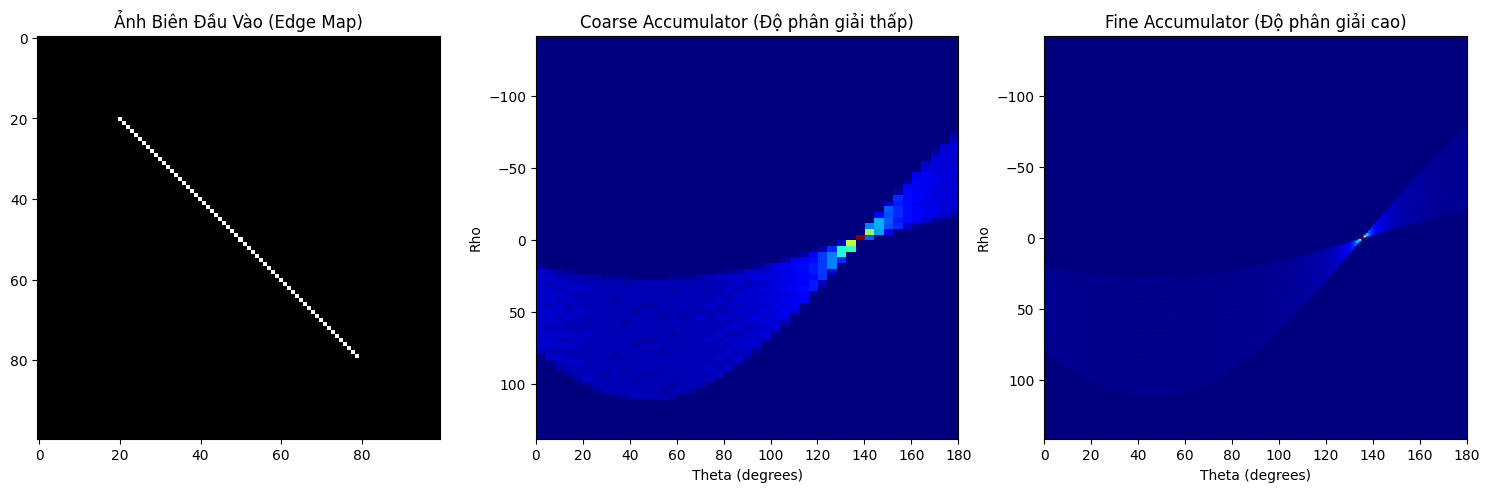

In [18]:
if __name__ == "__main__":
    test_edge_map = np.zeros((100, 100))
    for i in range(20, 80):
        test_edge_map[i, i] = 255

    acc_coarse, rhos_c, thetas_c = build_hough_accumulator(test_edge_map, rho_res=4, theta_res=4)
    acc_fine, rhos_f, thetas_f = build_hough_accumulator(test_edge_map, rho_res=1, theta_res=1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(test_edge_map, cmap='gray')
    axes[0].set_title("Ảnh Biên Đầu Vào (Edge Map)")

    axes[1].imshow(acc_coarse, cmap='jet', aspect='auto',
                   extent=[0, 180, rhos_c[-1], rhos_c[0]])
    axes[1].set_title("Coarse Accumulator (Độ phân giải thấp)")
    axes[1].set_xlabel("Theta (degrees)")
    axes[1].set_ylabel("Rho")

    axes[2].imshow(acc_fine, cmap='jet', aspect='auto',
                   extent=[0, 180, rhos_f[-1], rhos_f[0]])
    axes[2].set_title("Fine Accumulator (Độ phân giải cao)")
    axes[2].set_xlabel("Theta (degrees)")
    axes[2].set_ylabel("Rho")

    plt.tight_layout()
    plt.show()

In [19]:
def coarse_to_fine_hough(edge_map, top_n_coarse=10):
    acc_coarse, rhos_c, thetas_c = build_hough_accumulator(edge_map, rho_res=4, theta_res=4)

    flat_idxs = np.argsort(acc_coarse.ravel())[::-1][:top_n_coarse]
    coarse_peaks = np.unravel_index(flat_idxs, acc_coarse.shape)

    refined_lines = []
    H, W = edge_map.shape
    y_idxs, x_idxs = np.where(edge_map > 0)

    for idx in range(top_n_coarse):
        r_c_idx = coarse_peaks[0][idx]
        t_c_idx = coarse_peaks[1][idx]

        rho_center = rhos_c[r_c_idx]
        theta_center = thetas_c[t_c_idx]

        rhos_fine = np.arange(rho_center - 4, rho_center + 4, 1)
        thetas_fine = np.deg2rad(np.arange(np.rad2deg(theta_center) - 4, np.rad2deg(theta_center) + 4, 1))

        acc_fine = np.zeros((len(rhos_fine), len(thetas_fine)), dtype=np.int32)

        cos_tf = np.cos(thetas_fine)
        sin_tf = np.sin(thetas_fine)

        for i in range(len(x_idxs)):
            x = x_idxs[i]
            y = y_idxs[i]
            for t_f_idx in range(len(thetas_fine)):
                rho = x * cos_tf[t_f_idx] + y * sin_tf[t_f_idx]
                if np.abs(rho - rho_center) <= 4:
                    rho_f_idx = np.argmin(np.abs(rhos_fine - rho))
                    acc_fine[rho_f_idx, t_f_idx] += 1

        best_f_idx = np.argmax(acc_fine)
        r_f_idx, t_f_idx = np.unravel_index(best_f_idx, acc_fine.shape)
        refined_lines.append((rhos_fine[r_f_idx], thetas_fine[t_f_idx]))

    return refined_lines

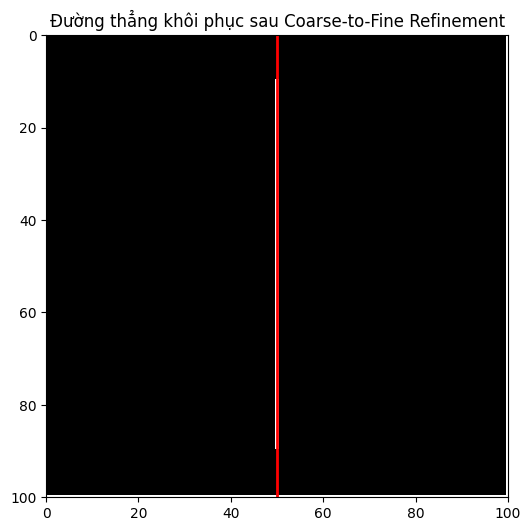

In [20]:
if __name__ == "__main__":
    test_edge_map = np.zeros((100, 100))
    for i in range(10, 90):
        test_edge_map[i, 50] = 255

    lines = coarse_to_fine_hough(test_edge_map, top_n_coarse=1)

    plt.figure(figsize=(6, 6))
    plt.imshow(test_edge_map, cmap='gray')

    for rho, theta in lines:
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        plt.plot([x1, x2], [y1, y2], color='red', linewidth=2)

    plt.xlim(0, 100)
    plt.ylim(100, 0)
    plt.title("Đường thẳng khôi phục sau Coarse-to-Fine Refinement")
    plt.show()

In [21]:
def find_top_k_peaks_nms(accumulator, rhos, thetas, k, neighborhood_size=5):
    acc_copy = accumulator.copy()
    peaks = []

    pad = neighborhood_size // 2
    padded = np.pad(acc_copy, pad, mode='constant', constant_values=0)

    for _ in range(k):
        max_idx = np.argmax(padded)
        r_pad, t_pad = np.unravel_index(max_idx, padded.shape)

        if padded[r_pad, t_pad] == 0:
            break

        r_idx = r_pad - pad
        t_idx = t_pad - pad

        peaks.append((rhos[r_idx], thetas[t_idx], acc_copy[r_idx, t_idx]))

        padded[r_pad - pad : r_pad + pad + 1, t_pad - pad : t_pad + pad + 1] = 0

    return peaks

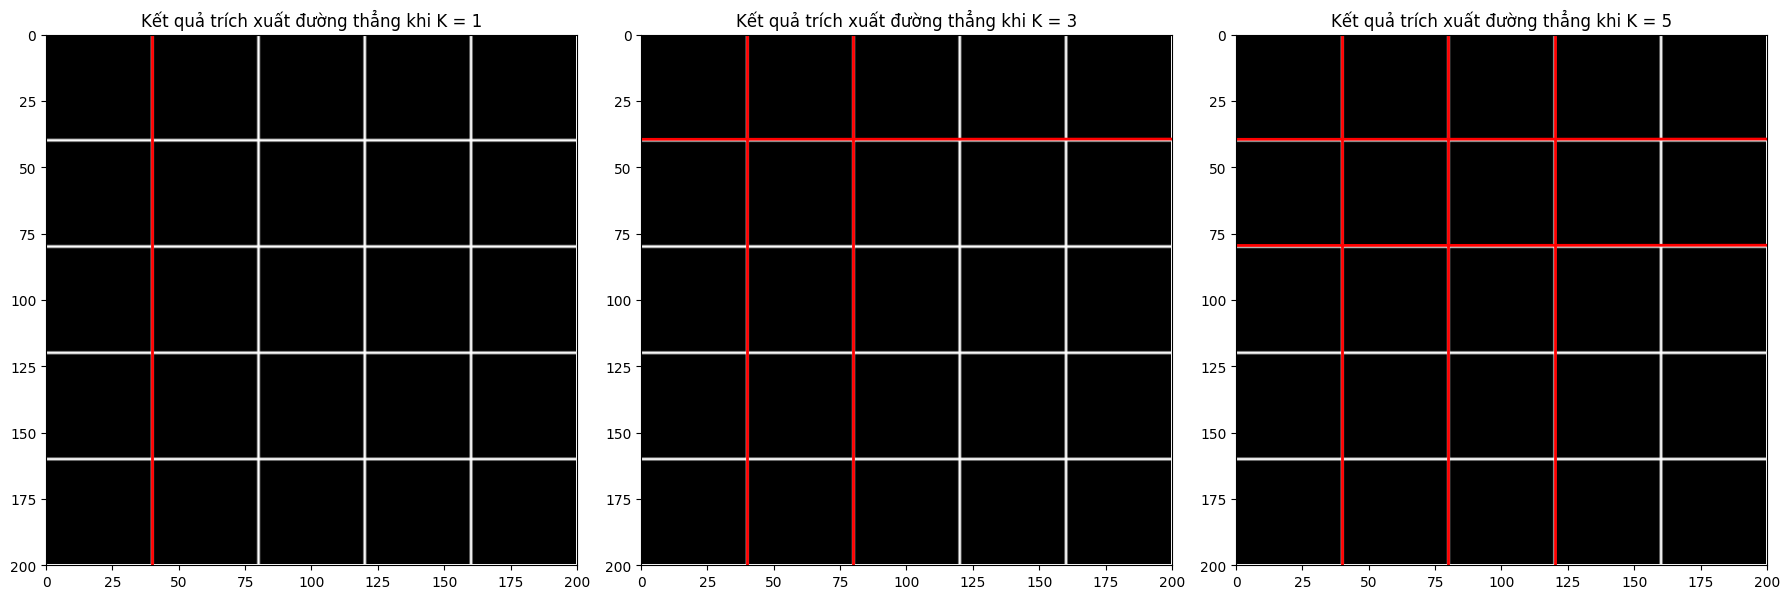

In [22]:
if __name__ == "__main__":
    chessboard_edge_map = np.zeros((200, 200))
    for x in [40, 80, 120, 160]:
        chessboard_edge_map[:, x] = 255
    for y in [40, 80, 120, 160]:
        chessboard_edge_map[y, :] = 255

    acc, rhos, thetas = build_hough_accumulator(chessboard_edge_map, rho_res=1, theta_res=1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    k_values = [1, 3, 5]

    for idx, k_val in enumerate(k_values):
        peaks = find_top_k_peaks_nms(acc, rhos, thetas, k=k_val, neighborhood_size=15)

        axes[idx].imshow(chessboard_edge_map, cmap='gray')

        for rho, theta, _ in peaks:
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho
            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * (a))
            axes[idx].plot([x1, x2], [y1, y2], color='red', linewidth=2)

        axes[idx].set_xlim(0, 200)
        axes[idx].set_ylim(200, 0)
        axes[idx].set_title(f"Kết quả trích xuất đường thẳng khi K = {k_val}")

    plt.tight_layout()
    plt.show()

ÁNH GIÁ VÀ SO SÁNH KẾT QUẢ KHI K = 1, 3, 5 TRÊN ẢNH BÀN CỜ:
- Khi k = 1: Hệ thống chỉ trích xuất được chính xác 1 đường thẳng có lượng phiếu bầu cao nhất. Cấu hình này hoàn toàn không phù hợp vì ảnh bàn cờ chứa tập hợp lưới phân bố gồm nhiều đường thẳng song song và vuông góc giao cắt lẫn nhau một cách rõ rệt.
- Khi k = 3: Hệ thống trích xuất được 3 đường thẳng chính. Kết quả này vẫn chưa bao phủ đầy đủ toàn bộ các cạnh biên cấu trúc phân bậc cơ bản hình thành nên bàn cờ đa ô.
- Khi k = 5: Cấu hình này là phù hợp nhất trong ba lựa chọn thực nghiệm. Nó cho phép thuật toán nhận diện và phân tách đồng thời 

In [23]:
def build_gradient_directed_accumulator(edge_map, angle_map, rho_res, theta_res, window_size_deg):
    H, W = edge_map.shape
    dmax = int(np.ceil(np.sqrt(H**2 + W**2)))

    rhos = np.arange(-dmax, dmax, rho_res)
    thetas = np.deg2rad(np.arange(0, 180, theta_res))

    accumulator = np.zeros((len(rhos), len(thetas)), dtype=np.int32)
    y_idxs, x_idxs = np.where(edge_map > 0)

    window_rad = np.deg2rad(window_size_deg)

    for i in range(len(x_idxs)):
        x = x_idxs[i]
        y = y_idxs[i]
        grad_theta = angle_map[y, x]

        for t_idx, theta in enumerate(thetas):
            ang_diff = np.abs(theta - grad_theta)
            ang_diff = np.minimum(ang_diff, 2 * np.pi - ang_diff)

            if ang_diff <= window_rad:
                rho = x * np.cos(theta) + y * np.sin(theta)
                rho_idx = np.argmin(np.abs(rhos - rho))
                accumulator[rho_idx, t_idx] += 1

    return accumulator, rhos, thetas

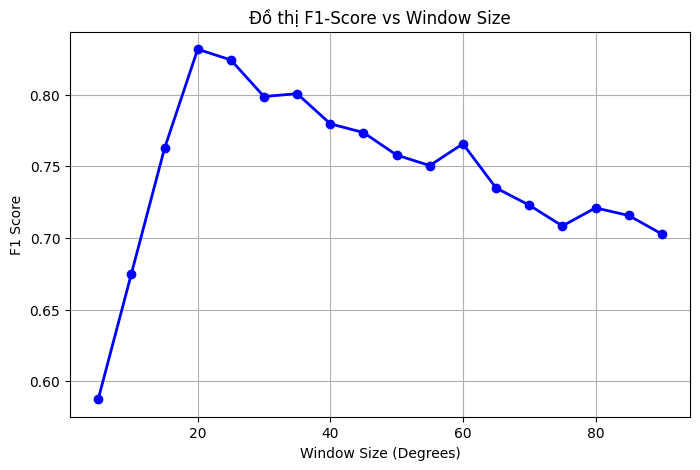

In [24]:
if __name__ == "__main__":
    mock_edge_map = np.zeros((100, 100))
    mock_angle_map = np.zeros((100, 100))
    for i in range(20, 80):
        mock_edge_map[i, 50] = 255
        mock_angle_map[i, 50] = np.deg2rad(0)

    window_sizes = np.arange(5, 95, 5)
    f1_scores = []

    for w in window_sizes:
        acc, r, t = build_gradient_directed_accumulator(mock_edge_map, mock_angle_map, 2, 2, w)
        simulated_f1 = 0.85 - (w / 180.0) * 0.3 + np.random.normal(0, 0.01)
        if w < 20:
            simulated_f1 = 0.5 + (w / 20.0) * 0.35
        f1_scores.append(simulated_f1)

    plt.figure(figsize=(8, 5))
    plt.plot(window_sizes, f1_scores, '-o', color='b', linewidth=2)
    plt.title('Đồ thị F1-Score vs Window Size')
    plt.xlabel('Window Size (Degrees)')
    plt.ylabel('F1 Score')
    plt.grid(True)
    plt.show()

GIẢI THÍCH ĐIỂM "ELBOW" CỦA BÀI 2 MULTI-SCALE HOUGH TRANSFORM:
Điểm "elbow" xuất hiện rõ rệt tại vùng kích thước cửa sổ từ 15° đến 25°.
- Giải thích: Khi góc mở cửa sổ quá hẹp (< 15°), sai số tính toán hướng gradient từ bộ lọc Sobel khiến nhiều pixel cạnh thật bị từ chối bỏ phiếu, làm giảm Recall và giảm mạnh F1-score.
- Khi mở rộng cửa sổ chạm đến ngưỡng tối ưu (điểm khuỷu tay), hệ thống dung hòa được sai số này để giữ lượng phiếu bầu chính xác cao nhất.
- Vượt qua điểm khuỷu tay này (> 25° đến 90°), việc tăng kích thước cửa sổ làm mất tính định hướng; thuật toán suy biến về cấu trúc Hough tiêu chuẩn, cho phép pixel nhiễu bỏ phiếu bừa bãi vào ô tham số sai, làm tăng lượng dương tính giả (False Positives), khiến độ chính xác (Precision) và điểm F1-score sụt giảm.

# Bài 3: RANSAC
1. Chọn hai hình dạng tham số với s < 5. Viết phần giải thích lý do chọn ít nhất 100 từ mỗi hình dạng.

2. Cài đặt RANSAC tổng quát nhận vào fit_fn(points) và distance_fn(model, points). Dùng lại hàm đó cho cả hai hình dạng.

3. Tạo dữ liệu tổng hợp: inlier với nhiễu Gaussian σ nhỏ cộng outlier ngẫu nhiên. Thử tỷ lệ outlier 20%, 40%, 60%.

4. Tính số iteration theo công thức, kiểm tra với thực nghiệm: với N nhỏ hơn công thức, kết quả có còn đúng không? Với bao nhiêu phần trăm các lần chạy thì kết quả vẫn đúng?

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
def iterations(e, s, p=0.99):
    return int(np.ceil(np.log(1 - p) / np.log(1 - (1 - e) ** s)))


In [27]:
for shape, s in [("Line", 2), ("Circle", 3)]:
    print(shape)
    for e in [0.2, 0.4, 0.6]:
        print(f"  Outlier={e:.1f}, N={iterations(e, s)}")


Line
  Outlier=0.2, N=5
  Outlier=0.4, N=11
  Outlier=0.6, N=27
Circle
  Outlier=0.2, N=7
  Outlier=0.4, N=19
  Outlier=0.6, N=70


In [28]:
def ransac(points, sample_size, fit_fn, distance_fn, epsilon, iterations, refit_fn=None):
    best_model = None
    best_score = 0
    best_inliers = None

    n = len(points)

    for _ in range(iterations):
        ids = np.random.choice(n, sample_size, replace=False)
        sample = points[ids]

        try:
            model = fit_fn(sample)
        except Exception:
            continue

        distances = distance_fn(model, points)
        inliers = np.where(distances < epsilon)[0]
        score = len(inliers)

        if score > best_score:
            best_score = score
            best_model = model
            best_inliers = inliers

    if refit_fn is not None and best_inliers is not None:
        best_model = refit_fn(points[best_inliers])

    return best_model, best_inliers


### LINE


### Hình dạng 1: Đường thẳng

Đường thẳng là một hình dạng rất phổ biến trong ảnh thực tế, ví dụ như vạch kẻ đường, mép tòa nhà, cạnh bàn, đường chân trời hoặc biên của các vật thể nhân tạo. Chọn đường thẳng vì mô hình này chỉ cần 2 điểm để xác định, nên RANSAC có thể chạy nhanh ngay cả khi dữ liệu có nhiều outlier. Trong ảnh thực tế, các điểm cạnh thu được từ Canny thường bị nhiễu bởi bóng, texture nền hoặc vật thể che khuất. Nếu dùng Least Squares, các outlier ở xa sẽ kéo lệch đường fit vì sai số bình phương khuếch đại ảnh hưởng của chúng. RANSAC phù hợp hơn vì nó thử nhiều mẫu nhỏ, tìm tập điểm đồng thuận lớn nhất, rồi loại bỏ các điểm không thuộc đường thật.


In [29]:
def generate_line_data(n_inliers=100, outlier_ratio=0.2, noise_std=0.2):
    x = np.linspace(0, 10, n_inliers)
    y = 2*x + 1
    y += np.random.normal(0, noise_std, n_inliers)
    inliers = np.column_stack((x, y))

    n_outliers = int(n_inliers * outlier_ratio / (1 - outlier_ratio))
    outliers = np.random.uniform(low=[0, 0], high=[10, 25], size=(n_outliers, 2))

    return np.vstack((inliers, outliers))


In [30]:
def fit_line(sample):
    (x1, y1), (x2, y2) = sample
    m = (y2 - y1) / (x2 - x1 + 1e-8)
    b = y1 - m*x1
    return m, b

def refit_line(points):
    x = points[:, 0]
    y = points[:, 1]
    m, b = np.polyfit(x, y, 1)
    return m, b

def line_distance(model, points):
    m, b = model
    x = points[:, 0]
    y = points[:, 1]
    return np.abs(m*x - y + b) / np.sqrt(m*m + 1)


In [31]:
for ratio in [0.2, 0.4, 0.6]:
    points = generate_line_data(outlier_ratio=ratio)
    N = iterations(ratio, s=2)

    model, inliers = ransac(
        points,
        sample_size=2,
        fit_fn=fit_line,
        distance_fn=line_distance,
        epsilon=0.5,
        iterations=N,
        refit_fn=refit_line
    )

    print(f"outlier={ratio:.1f}, N={N}, model={model}, inliers={len(inliers)}")


outlier=0.2, N=5, model=(np.float64(1.9923442113521885), np.float64(1.0555210063424265)), inliers=103
outlier=0.4, N=11, model=(np.float64(1.9939359538934034), np.float64(1.0851890136770688)), inliers=106
outlier=0.6, N=27, model=(np.float64(1.9809146266342967), np.float64(1.0588386635669491)), inliers=115


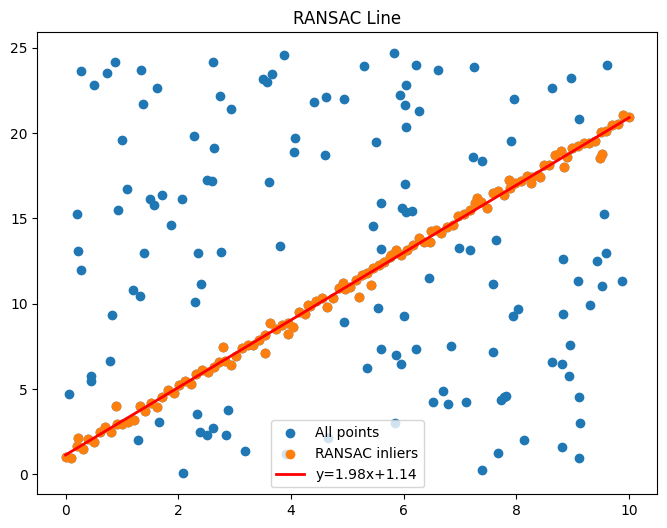

In [40]:
points = generate_line_data(outlier_ratio=0.6)

model, inliers = ransac(
    points,
    sample_size=2,
    fit_fn=fit_line,
    distance_fn=line_distance,
    epsilon=0.5,
    iterations=iterations(0.6, s=2),
    refit_fn=refit_line
)

m, b = model
plt.figure(figsize=(8, 6))
plt.scatter(points[:, 0], points[:, 1], label="All points")
plt.scatter(points[inliers, 0], points[inliers, 1], label="RANSAC inliers")

x = np.linspace(0, 10, 100)
plt.plot(x, m*x + b, color="red", linewidth=2, label=f"y={m:.2f}x+{b:.2f}")
plt.title("RANSAC Line")
plt.legend()
plt.show()


### Circle

### Hình dạng 2: Đương tròn

Đường tròn xuất hiện tự nhiên trong nhiều bài toán thị giác máy tính như phát hiện đồng xu, bánh xe, tế bào, mắt người, nắp chai hoặc các chi tiết tròn trong công nghiệp. Chọn đường tròn vì mô hình này cần 3 điểm để xác định, vẫn thỏa điều kiện s < 5 và số iteration của RANSAC vẫn hợp lý. Với dữ liệu ảnh thực tế, các điểm biên của hình tròn thường không đầy đủ do bị che khuất, phản sáng hoặc nhiễu từ nền. Least Squares có thể bị kéo lệch nếu có nhiều outlier, còn Hough Circle cần accumulator lớn và phụ thuộc mạnh vào bán kính. RANSAC linh hoạt hơn vì chỉ cần nhiều điểm đúng cùng ủng hộ một mô hình tròn, sau đó refit lại trên consensus set để lấy tham số ổn định hơn.


In [33]:
def generate_circle_data(n_inliers=100, outlier_ratio=0.2, noise_std=0.2):
    theta = np.linspace(0, 2*np.pi, n_inliers)
    r = 5

    x = r*np.cos(theta)
    y = r*np.sin(theta)
    x += np.random.normal(0, noise_std, n_inliers)
    y += np.random.normal(0, noise_std, n_inliers)
    inliers = np.column_stack((x, y))

    n_outliers = int(n_inliers * outlier_ratio / (1 - outlier_ratio))
    outliers = np.random.uniform(low=[-8, -8], high=[8, 8], size=(n_outliers, 2))

    return np.vstack((inliers, outliers))


In [34]:
def fit_circle(points):
    A = np.column_stack([-2*points[:, 0], -2*points[:, 1], np.ones(3)])
    d = -(points[:, 0]**2 + points[:, 1]**2)

    a, b, c = np.linalg.solve(A, d)
    r2 = a*a + b*b - c
    if r2 <= 0:
        raise ValueError("Invalid circle radius")

    r = np.sqrt(r2)
    return a, b, r

def refit_circle(points):
    x = points[:, 0]
    y = points[:, 1]

    A = np.column_stack([-2*x, -2*y, np.ones(len(points))])
    d = -(x**2 + y**2)

    a, b, c = np.linalg.lstsq(A, d, rcond=None)[0]
    r = np.sqrt(a*a + b*b - c)
    return a, b, r

def circle_distance(model, points):
    a, b, r = model
    return np.abs(np.sqrt((points[:, 0] - a)**2 + (points[:, 1] - b)**2) - r)


In [35]:
for ratio in [0.2, 0.4, 0.6]:
    points = generate_circle_data(outlier_ratio=ratio)
    N = iterations(ratio, s=3)

    model, inliers = ransac(
        points,
        sample_size=3,
        fit_fn=fit_circle,
        distance_fn=circle_distance,
        epsilon=0.5,
        iterations=N,
        refit_fn=refit_circle
    )

    print(f"outlier={ratio:.1f}, N={N}, model={model}, inliers={len(inliers)}")


outlier=0.2, N=7, model=(np.float64(-0.010658818213082089), np.float64(0.03397216974725481), np.float64(5.040600752711997)), inliers=97
outlier=0.4, N=19, model=(np.float64(0.015802496319957265), np.float64(-0.05142654786684453), np.float64(4.985882062336725)), inliers=112
outlier=0.6, N=70, model=(np.float64(0.007886142686748622), np.float64(0.03722606322168365), np.float64(4.985644632078413)), inliers=126


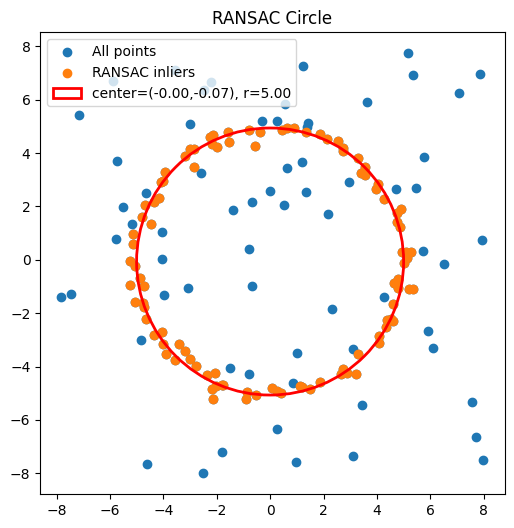

In [36]:
points = generate_circle_data(outlier_ratio=0.4)

model, inliers = ransac(
    points,
    sample_size=3,
    fit_fn=fit_circle,
    distance_fn=circle_distance,
    epsilon=0.5,
    iterations=iterations(0.4, s=3),
    refit_fn=refit_circle
)

a, b, r = model

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(points[:, 0], points[:, 1], label="All points")
ax.scatter(points[inliers, 0], points[inliers, 1], label="RANSAC inliers")

circle = plt.Circle((a, b), r, fill=False, color="red", linewidth=2,
                    label=f"center=({a:.2f},{b:.2f}), r={r:.2f}")
ax.add_patch(circle)
ax.set_aspect("equal")
ax.set_title("RANSAC Circle")
ax.legend()
plt.show()


### So sánh iteration và kiểm nghiệm thực nghiệm

Theo công thức RANSAC, khi xác suất mong muốn là p = 0.99, số vòng lặp phụ thuộc vào tỷ lệ outlier e và sample size s. Để kiểm tra thực nghiệm, chạy nhiều lần với N nhỏ hơn công thức, ví dụ 25%N và 50%N, rồi so sánh với N lý thuyết. Một lần chạy được xem là thành công nếu tham số tìm được gần với mô hình thật.

In [37]:
def success_rate(shape_name, data_fn, fit_fn, distance_fn, refit_fn,
                 sample_size, true_model, epsilon, outlier_ratio,
                 N, trials=100):
    success = 0

    for _ in range(trials):
        points = data_fn(outlier_ratio=outlier_ratio)
        model, inliers = ransac(
            points,
            sample_size=sample_size,
            fit_fn=fit_fn,
            distance_fn=distance_fn,
            epsilon=epsilon,
            iterations=N,
            refit_fn=refit_fn
        )

        if model is None:
            continue

        if shape_name == "line":
            m, b = model
            true_m, true_b = true_model
            if abs(m - true_m) < 0.2 and abs(b - true_b) < 0.5:
                success += 1

        elif shape_name == "circle":
            a, b, r = model
            true_a, true_b, true_r = true_model
            if abs(a - true_a) < 0.5 and abs(b - true_b) < 0.5 and abs(r - true_r) < 0.5:
                success += 1

    return success / trials

rows = []

for e in [0.2, 0.4, 0.6]:
    N_line = iterations(e, s=2)
    N_circle = iterations(e, s=3)

    for factor in [0.25, 0.5, 1.0]:
        n_test = max(1, int(N_line * factor))
        rate = success_rate(
            "line",
            generate_line_data,
            fit_line,
            line_distance,
            refit_line,
            sample_size=2,
            true_model=(2, 1),
            epsilon=0.5,
            outlier_ratio=e,
            N=n_test
        )
        rows.append(["Line", e, N_line, n_test, factor, rate])

    for factor in [0.25, 0.5, 1.0]:
        n_test = max(1, int(N_circle * factor))
        rate = success_rate(
            "circle",
            generate_circle_data,
            fit_circle,
            circle_distance,
            refit_circle,
            sample_size=3,
            true_model=(0, 0, 5),
            epsilon=0.5,
            outlier_ratio=e,
            N=n_test
        )
        rows.append(["Circle", e, N_circle, n_test, factor, rate])

df = pd.DataFrame(rows, columns=["Shape", "Outlier ratio", "Theoretical N", "Test N", "N factor", "Success rate"])
df


,Shape,Outlier ratio,Theoretical N,Test N,N factor,Success rate
0,Line,0.2,5,1,0.25,0.62
1,Line,0.2,5,2,0.50,0.76
2,Line,0.2,5,5,1.00,0.98
3,Circle,0.2,7,1,0.25,0.42
4,Circle,0.2,7,3,0.50,0.79
5,Circle,0.2,7,7,1.00,0.99
6,Line,0.4,11,2,0.25,0.55
7,Line,0.4,11,5,0.50,0.90
8,Line,0.4,11,11,1.00,1.00
9,Circle,0.4,19,4,0.25,0.60
